In [1]:
import random
import os
import zipfile
import pickle
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Random seed
seed = 7
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Seed set to:", seed)
print("Device:", device)

Seed set to: 7
Device: cuda


# Data Loading and Preprocessing

In [3]:
zip_path = "ECE1508Dataset.zip"
extract_path = "metr_la_data"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

for root, dirs, files in os.walk(extract_path):
    print("Folder:", root)
    for f in files:
        print("  ", f)

Folder: metr_la_data
   adj_METR-LA.pkl
   METR-LA.h5


In [4]:
h5_path = None
for root, dirs, files in os.walk("metr_la_data"):
    for f in files:
        if f.endswith(".h5"):
            h5_path = os.path.join(root, f)

print("h5_path =", h5_path)

df = pd.read_hdf(h5_path)
print("shape:", df.shape)
display(df.head())

h5_path = metr_la_data/METR-LA.h5
shape: (34272, 207)


,773869,767541,767542,717447,717446,717445,773062,767620,737529,717816,...,772167,769372,774204,769806,717590,717592,717595,772168,718141,769373
2012-03-01 00:00:00,64.375000,67.625000,67.125000,61.500000,66.875000,68.750000,65.125,67.125,59.625000,62.750000,...,45.625000,65.500,64.500000,66.428571,66.875,59.375000,69.000000,59.250000,69.000000,61.875
2012-03-01 00:05:00,62.666667,68.555556,65.444444,62.444444,64.444444,68.111111,65.000,65.000,57.444444,63.333333,...,50.666667,69.875,66.666667,58.555556,62.000,61.111111,64.444444,55.888889,68.444444,62.875
2012-03-01 00:10:00,64.000000,63.750000,60.000000,59.000000,66.500000,66.250000,64.500,64.250,63.875000,65.375000,...,44.125000,69.000,56.500000,59.250000,68.125,62.500000,65.625000,61.375000,69.857143,62.000
2012-03-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000
2012-03-01 00:20:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000,0.000,0.000000,0.000000,...,0.000000,0.000,0.000000,0.000000,0.000,0.000000,0.000000,0.000000,0.000000,0.000


In [5]:
print("index type:", type(df.index))
print("first 5 timestamps:", df.index[:5].tolist())
print("first 10 sensor ids:", df.columns[:10].tolist())

index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
first 5 timestamps: [Timestamp('2012-03-01 00:00:00'), Timestamp('2012-03-01 00:05:00'), Timestamp('2012-03-01 00:10:00'), Timestamp('2012-03-01 00:15:00'), Timestamp('2012-03-01 00:20:00')]
first 10 sensor ids: ['773869', '767541', '767542', '717447', '717446', '717445', '773062', '767620', '737529', '717816']


In [6]:
data = df.values

print("data shape:", data.shape)
print(data[:3, :5])

data shape: (34272, 207)
[[64.375      67.625      67.125      61.5        66.875     ]
 [62.66666667 68.55555556 65.44444444 62.44444444 64.44444444]
 [64.         63.75       60.         59.         66.5       ]]


In [7]:
data = np.expand_dims(data, axis=-1)

print("new shape:", data.shape)

new shape: (34272, 207, 1)


In [8]:
def create_sequences(data, input_len=12, pred_len=12):
    X = []
    y = []

    T = data.shape[0]

    for i in range(T - input_len - pred_len + 1):
        X.append(data[i:i + input_len])
        y.append(data[i + input_len:i + input_len + pred_len])

    return np.array(X), np.array(y)

X, y = create_sequences(data, input_len=12, pred_len=12)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (34249, 12, 207, 1)
y shape: (34249, 12, 207, 1)


In [9]:
num_samples = X.shape[0]

train_size = int(num_samples * 0.7)
val_size = int(num_samples * 0.1)
test_size = num_samples - train_size - val_size

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

In [10]:
print("Before reshape:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Before reshape:
X_train: (23974, 12, 207, 1)
y_train: (23974, 12, 207, 1)
X_val: (3424, 12, 207, 1)
y_val: (3424, 12, 207, 1)
X_test: (6851, 12, 207, 1)
y_test: (6851, 12, 207, 1)


# Baseline LSTM

In [11]:
X_train_lstm = X_train.squeeze(-1)
X_val_lstm = X_val.squeeze(-1)
X_test_lstm = X_test.squeeze(-1)

y_train_lstm = y_train.squeeze(-1)
y_val_lstm = y_val.squeeze(-1)
y_test_lstm = y_test.squeeze(-1)

print("After reshape:")
print("X_train_lstm:", X_train_lstm.shape)
print("y_train_lstm:", y_train_lstm.shape)
print("X_val_lstm:", X_val_lstm.shape)
print("y_val_lstm:", y_val_lstm.shape)
print("X_test_lstm:", X_test_lstm.shape)
print("y_test_lstm:", y_test_lstm.shape)

After reshape:
X_train_lstm: (23974, 12, 207)
y_train_lstm: (23974, 12, 207)
X_val_lstm: (3424, 12, 207)
y_val_lstm: (3424, 12, 207)
X_test_lstm: (6851, 12, 207)
y_test_lstm: (6851, 12, 207)


In [12]:
# Per-node z-score normalization
null_val = 0.0

node_mean = np.zeros(207, dtype=np.float32)
node_std = np.zeros(207, dtype=np.float32)

for n in range(207):
    valid_vals = X_train_lstm[:, :, n]
    valid_vals = valid_vals[valid_vals != null_val]
    node_mean[n] = valid_vals.mean()
    node_std[n] = valid_vals.std()
    if node_std[n] < 1e-6:
        node_std[n] = 1.0

print(f"node_mean range: [{node_mean.min():.2f}, {node_mean.max():.2f}]")
print(f"node_std range: [{node_std.min():.2f}, {node_std.max():.2f}]")

def normalize_per_node(arr, mean, std, null_val=0.0):
    out = arr.copy().astype(np.float32)
    for n in range(207):
        m = out[:, :, n] != null_val
        out[:, :, n][m] = (out[:, :, n][m] - mean[n]) / (std[n] + 1e-8)
    return out

def denormalize_per_node(arr, mean, std):
    out = arr.copy()
    for n in range(207):
        out[:, :, n] = out[:, :, n] * (std[n] + 1e-8) + mean[n]
    return out

X_train_lstm = normalize_per_node(X_train_lstm, node_mean, node_std)
X_val_lstm = normalize_per_node(X_val_lstm, node_mean, node_std)
X_test_lstm = normalize_per_node(X_test_lstm, node_mean, node_std)

y_train_lstm = normalize_per_node(y_train_lstm, node_mean, node_std)
y_val_lstm = normalize_per_node(y_val_lstm, node_mean, node_std)
y_test_lstm = normalize_per_node(y_test_lstm, node_mean, node_std)

print(f"X_train_lstm mean (non-zero): {X_train_lstm[X_train_lstm != 0].mean():.4f}")
print(f"X_train_lstm std (non-zero): {X_train_lstm[X_train_lstm != 0].std():.4f}")

node_mean range: [30.87, 67.76]
node_std range: [2.03, 23.59]
X_train_lstm mean (non-zero): 0.0000
X_train_lstm std (non-zero): 1.0000


In [13]:
# mask out missing values (zero readings) before computing loss
def masked_mae_loss(y_pred, y_true, null_val=0.0):
    mask = (y_true != null_val).float()
    mask = mask / (mask.mean() + 1e-8)
    loss = torch.abs(y_pred - y_true) * mask
    return loss.mean()

In [14]:
X_train_tensor = torch.tensor(X_train_lstm, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_lstm, dtype=torch.float32)

X_val_tensor = torch.tensor(X_val_lstm, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_lstm, dtype=torch.float32)

X_test_tensor = torch.tensor(X_test_lstm, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_lstm, dtype=torch.float32)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [15]:
class BaselineLSTM(nn.Module):
    def __init__(self, input_size=207, hidden_size=64, num_layers=2, output_size=207, pred_len=12, dropout=0.2):
        super().__init__()
        self.pred_len = pred_len
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )
        self.fc = nn.Linear(hidden_size, output_size * pred_len)

    def forward(self, x):
        out, (h_n, c_n) = self.lstm(x)
        last_out = out[:, -1, :]
        y_hat = self.fc(last_out)
        return y_hat.view(y_hat.size(0), self.pred_len, -1)

In [16]:
model = BaselineLSTM(
    input_size=207,
    hidden_size=64,
    num_layers=2,
    output_size=207,
    dropout=0.2
).to(device)

lstm_optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)

BaselineLSTM(
  (lstm): LSTM(207, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=2484, bias=True)
)


In [17]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss = 0.0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = masked_mae_loss(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = masked_mae_loss(preds, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [18]:
lstm_train_losses = []
lstm_val_losses = []

lstm_best_val_loss = float('inf')
lstm_best_model_wts = None
patience = 10
lstm_no_improve = 0
num_epochs = 100

for epoch in range(1, num_epochs + 1):
    train_loss = train_one_epoch(model, train_loader, lstm_optimizer, device)
    val_loss = evaluate(model, val_loader, device)

    lstm_train_losses.append(train_loss)
    lstm_val_losses.append(val_loss)

    if val_loss < lstm_best_val_loss:
        lstm_best_val_loss = val_loss
        lstm_best_model_wts = copy.deepcopy(model.state_dict())
        lstm_no_improve = 0
        flag = " <- best"
    else:
        lstm_no_improve += 1
        flag = f" (no improve {lstm_no_improve}/{patience})"

    print(f"Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}{flag}")

    if lstm_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

model.load_state_dict(lstm_best_model_wts)
print(f"Best val loss: {lstm_best_val_loss:.4f}")

Epoch   1 | Train: 0.4224 | Val: 0.3891 <- best
Epoch   2 | Train: 0.3721 | Val: 0.3762 <- best
Epoch   3 | Train: 0.3584 | Val: 0.3688 <- best
Epoch   4 | Train: 0.3504 | Val: 0.3678 <- best
Epoch   5 | Train: 0.3451 | Val: 0.3663 <- best
Epoch   6 | Train: 0.3411 | Val: 0.3650 <- best
Epoch   7 | Train: 0.3375 | Val: 0.3630 <- best
Epoch   8 | Train: 0.3351 | Val: 0.3631 (no improve 1/10)
Epoch   9 | Train: 0.3328 | Val: 0.3617 <- best
Epoch  10 | Train: 0.3311 | Val: 0.3629 (no improve 1/10)
Epoch  11 | Train: 0.3297 | Val: 0.3613 <- best
Epoch  12 | Train: 0.3282 | Val: 0.3636 (no improve 1/10)
Epoch  13 | Train: 0.3269 | Val: 0.3632 (no improve 2/10)
Epoch  14 | Train: 0.3259 | Val: 0.3630 (no improve 3/10)
Epoch  15 | Train: 0.3249 | Val: 0.3638 (no improve 4/10)
Epoch  16 | Train: 0.3241 | Val: 0.3622 (no improve 5/10)
Epoch  17 | Train: 0.3233 | Val: 0.3635 (no improve 6/10)
Epoch  18 | Train: 0.3225 | Val: 0.3633 (no improve 7/10)
Epoch  19 | Train: 0.3219 | Val: 0.3636 (no im

In [19]:
model.eval()

lstm_all_preds = []
lstm_all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds = model(X_batch).cpu()

        lstm_all_preds.append(preds)
        lstm_all_targets.append(y_batch)

lstm_all_preds = torch.cat(lstm_all_preds, dim=0).numpy()
lstm_all_targets = torch.cat(lstm_all_targets, dim=0).numpy()

print("pred shape:", lstm_all_preds.shape)
print("target shape:", lstm_all_targets.shape)

pred shape: (6851, 12, 207)
target shape: (6851, 12, 207)


In [20]:
lstm_preds_denorm = denormalize_per_node(lstm_all_preds, node_mean, node_std)
lstm_targets_denorm = denormalize_per_node(lstm_all_targets, node_mean, node_std)

In [21]:
def MAE(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def RMSE(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def MAPE(y_true, y_pred):
    mask = y_true > 10
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate_multistep(targets, preds, horizons=[3, 6, 12]):
    print(f"{'Horizon':<10} {'MAE':>10} {'RMSE':>10} {'MAPE':>10}")
    print("=" * 45)
    for h in horizons:
        t = targets[:, h-1, :]
        p = preds[:, h-1, :]
        mae = MAE(t, p)
        rmse = RMSE(t, p)
        mape = MAPE(t, p)
        print(f"{f'H{h} ({h*5}min)':<10} {mae:>10.4f} {rmse:>10.4f} {mape:>10.2f}%")
    print("=" * 45)
    overall_mae = MAE(targets, preds)
    overall_rmse = RMSE(targets, preds)
    overall_mape = MAPE(targets, preds)
    print(f"{'Overall':<10} {overall_mae:>10.4f} {overall_rmse:>10.4f} {overall_mape:>10.2f}%")

In [22]:
print("=== LSTM Results ===")
evaluate_multistep(lstm_targets_denorm, lstm_preds_denorm, horizons=[3, 6, 12])

=== LSTM Results ===
Horizon           MAE       RMSE       MAPE
H3 (15min)     3.6382     6.8735       9.09%
H6 (30min)     3.7120     7.0556       9.34%
H12 (60min)     3.9152     7.4708       9.99%
Overall        3.7395     7.1058       9.42%


# Temporal CNN baseline

In [23]:
X_train_tcn = X_train_lstm[..., np.newaxis]
X_val_tcn = X_val_lstm[..., np.newaxis]
X_test_tcn = X_test_lstm[..., np.newaxis]

y_train_tcn = y_train_lstm
y_val_tcn = y_val_lstm
y_test_tcn = y_test_lstm

print("X_train:", X_train_tcn.shape)
print("y_train:", y_train_tcn.shape)
print("mean check:", X_train_tcn.mean())

X_train: (23974, 12, 207, 1)
y_train: (23974, 12, 207)
mean check: 2.192755e-08


In [24]:
X_train_tcn_tensor = torch.tensor(X_train_tcn, dtype=torch.float32)
y_train_tcn_tensor = torch.tensor(y_train_tcn, dtype=torch.float32)

X_val_tcn_tensor = torch.tensor(X_val_tcn, dtype=torch.float32)
y_val_tcn_tensor = torch.tensor(y_val_tcn, dtype=torch.float32)

X_test_tcn_tensor = torch.tensor(X_test_tcn, dtype=torch.float32)
y_test_tcn_tensor = torch.tensor(y_test_tcn, dtype=torch.float32)

print(X_train_tcn_tensor.shape)
print(y_train_tcn_tensor.shape)

torch.Size([23974, 12, 207, 1])
torch.Size([23974, 12, 207])


In [25]:
train_dataset = TensorDataset(X_train_tcn_tensor, y_train_tcn_tensor)
val_dataset = TensorDataset(X_val_tcn_tensor, y_val_tcn_tensor)
test_dataset = TensorDataset(X_test_tcn_tensor, y_test_tcn_tensor)

train_loader_tcn = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader_tcn = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader_tcn = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [26]:
class TemporalCNN(nn.Module):
    def __init__(self, in_channels=1, hidden_channels=32, pred_len=12):
        super().__init__()
        self.pred_len = pred_len
        self.conv1 = nn.Conv2d(in_channels, hidden_channels, kernel_size=(3, 1), padding=(1, 0))
        self.conv2 = nn.Conv2d(hidden_channels, hidden_channels, kernel_size=(3, 1), padding=(1, 0))
        self.relu = nn.ReLU()
        self.final = nn.Conv2d(hidden_channels, pred_len, kernel_size=(1, 1))

    def forward(self, X):
        X = X.permute(0, 3, 1, 2)
        X = self.relu(self.conv1(X))
        X = self.relu(self.conv2(X))
        out = self.final(X)
        out = out[:, :, -1, :]
        return out

In [27]:
tcn_model = TemporalCNN(in_channels=1, hidden_channels=32).to(device)
tcn_optimizer = torch.optim.Adam(tcn_model.parameters(), lr=1e-3)

print(tcn_model)

TemporalCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
  (conv2): Conv2d(32, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
  (relu): ReLU()
  (final): Conv2d(32, 12, kernel_size=(1, 1), stride=(1, 1))
)


In [28]:
def train_epoch_tcn(model, loader, optimizer):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model(X_batch)
        loss = masked_mae_loss(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)


def eval_epoch_tcn(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch)
            loss = masked_mae_loss(preds, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [29]:
tcn_train_losses = []
tcn_val_losses = []

tcn_best_val_loss = float('inf')
tcn_best_model_wts = None
patience = 10
tcn_no_improve = 0
num_epochs = 100

for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch_tcn(tcn_model, train_loader_tcn, tcn_optimizer)
    val_loss = eval_epoch_tcn(tcn_model, val_loader_tcn)

    tcn_train_losses.append(train_loss)
    tcn_val_losses.append(val_loss)

    if val_loss < tcn_best_val_loss:
        tcn_best_val_loss = val_loss
        tcn_best_model_wts = copy.deepcopy(tcn_model.state_dict())
        tcn_no_improve = 0
        flag = " <- best"
    else:
        tcn_no_improve += 1
        flag = f" (no improve {tcn_no_improve}/{patience})"

    print(f"Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}{flag}")

    if tcn_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

tcn_model.load_state_dict(tcn_best_model_wts)
print(f"Best val loss: {tcn_best_val_loss:.4f}")

Epoch   1 | Train: 0.4053 | Val: 0.3790 <- best
Epoch   2 | Train: 0.3926 | Val: 0.3796 (no improve 1/10)
Epoch   3 | Train: 0.3923 | Val: 0.3787 <- best
Epoch   4 | Train: 0.3919 | Val: 0.3780 <- best
Epoch   5 | Train: 0.3915 | Val: 0.3783 (no improve 1/10)
Epoch   6 | Train: 0.3913 | Val: 0.3786 (no improve 2/10)
Epoch   7 | Train: 0.3911 | Val: 0.3772 <- best
Epoch   8 | Train: 0.3909 | Val: 0.3771 <- best
Epoch   9 | Train: 0.3910 | Val: 0.3776 (no improve 1/10)
Epoch  10 | Train: 0.3909 | Val: 0.3770 <- best
Epoch  11 | Train: 0.3908 | Val: 0.3773 (no improve 1/10)
Epoch  12 | Train: 0.3908 | Val: 0.3765 <- best
Epoch  13 | Train: 0.3907 | Val: 0.3769 (no improve 1/10)
Epoch  14 | Train: 0.3907 | Val: 0.3781 (no improve 2/10)
Epoch  15 | Train: 0.3907 | Val: 0.3773 (no improve 3/10)
Epoch  16 | Train: 0.3907 | Val: 0.3778 (no improve 4/10)
Epoch  17 | Train: 0.3906 | Val: 0.3770 (no improve 5/10)
Epoch  18 | Train: 0.3906 | Val: 0.3771 (no improve 6/10)
Epoch  19 | Train: 0.3906 

In [30]:
tcn_model.eval()

tcn_all_preds = []
tcn_all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_tcn:
        X_batch = X_batch.to(device)
        preds = tcn_model(X_batch).cpu()

        tcn_all_preds.append(preds)
        tcn_all_targets.append(y_batch)

tcn_all_preds = torch.cat(tcn_all_preds).numpy()
tcn_all_targets = torch.cat(tcn_all_targets).numpy()

print(tcn_all_preds.shape)

(6851, 12, 207)


In [31]:
tcn_preds_denorm = denormalize_per_node(tcn_all_preds, node_mean, node_std)
tcn_targets_denorm = denormalize_per_node(tcn_all_targets, node_mean, node_std)

In [32]:
print("=== Temporal CNN Results ===")
evaluate_multistep(tcn_targets_denorm, tcn_preds_denorm, horizons=[3, 6, 12])

=== Temporal CNN Results ===
Horizon           MAE       RMSE       MAPE
H3 (15min)     3.0020     5.9586       7.30%
H6 (30min)     3.6787     7.3712       9.32%
H12 (60min)     4.6354     9.0854      12.45%
Overall        3.6752     7.3988       9.38%


# STGCN (First-Order)

In [33]:
pkl_path = "/content/metr_la_data/adj_METR-LA.pkl"

with open(pkl_path, "rb") as f:
    sensor_ids, sensor_id_to_ind, adj_mx = pickle.load(f, encoding="latin1")

print("adj_mx shape:", adj_mx.shape)
print("num sensors:", len(sensor_ids))
print("adj sample:")
print(adj_mx[:5, :5])

adj_mx shape: (207, 207)
num sensors: 207
adj sample:
[[1.         0.         0.         0.         0.        ]
 [0.         1.         0.3909554  0.         0.        ]
 [0.         0.7174379  1.         0.         0.        ]
 [0.         0.         0.         1.         0.63372165]
 [0.         0.         0.         0.62646437 1.        ]]


In [34]:
A = adj_mx

# add self-loop
A_hat = A + np.eye(A.shape[0])

# degree matrix
D = np.diag(np.sum(A_hat, axis=1))

# D^(-1/2)
D_inv_sqrt = np.linalg.inv(np.sqrt(D))

# normalized adjacency
A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt

print("A_norm shape:", A_norm.shape)
print(A_norm[:5, :5])

A_norm shape: (207, 207)
[[0.34019118 0.         0.         0.         0.        ]
 [0.         0.41601695 0.07421152 0.         0.        ]
 [0.         0.13618474 0.34644732 0.         0.        ]
 [0.         0.         0.         0.27213984 0.08519316]
 [0.         0.         0.         0.08421754 0.2656319 ]]


In [35]:
A_norm = torch.tensor(A_norm, dtype=torch.float32).to(device)

print(A_norm.shape)

torch.Size([207, 207])


In [36]:
class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.linear = nn.Linear(in_channels, out_channels)

    def forward(self, X, A_norm):
        # X shape: (batch, nodes, features)
        AX = torch.matmul(A_norm, X)
        out = self.linear(AX)
        return out

In [37]:
class TemporalConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3):
        super().__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels * 2,
            (kernel_size, 1),
            padding=(kernel_size // 2, 0)
        )

    def forward(self, X):
        out = self.conv(X)
        P, Q = out.chunk(2, dim=1)
        return P * torch.sigmoid(Q)

In [38]:
class STGCNBlock(nn.Module):
    def __init__(self, in_channels, spatial_channels, out_channels, dropout=0.1):
        super().__init__()

        self.temp1 = TemporalConv(in_channels, spatial_channels)
        self.graph_conv = GraphConv(spatial_channels, spatial_channels)
        self.temp2 = TemporalConv(spatial_channels, out_channels)

        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm([out_channels])

        if in_channels != out_channels:
            self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 1))
        else:
            self.residual = nn.Identity()

    def forward(self, X, A_norm):
        residual = self.residual(X)

        t = self.temp1(X)

        B, C, T, N = t.shape
        t = t.permute(0, 2, 3, 1).reshape(B*T, N, C)
        t = self.graph_conv(t, A_norm)
        t = t.reshape(B, T, N, C).permute(0, 3, 1, 2)

        t = self.temp2(t)
        t = self.dropout(t)

        # residual connection
        t = t + residual

        t = t.permute(0, 2, 3, 1)
        t = self.norm(t)
        t = t.permute(0, 3, 1, 2)

        return t

In [39]:
class STGCN(nn.Module):
    def __init__(self, num_nodes=207, pred_len=12, spatial_channels=16):
        super().__init__()
        self.pred_len = pred_len
        self.block1 = STGCNBlock(in_channels=1, spatial_channels=spatial_channels, out_channels=64)
        self.block2 = STGCNBlock(in_channels=64, spatial_channels=spatial_channels, out_channels=64)
        self.final = nn.Conv2d(64, pred_len, (1, 1))

    def forward(self, X, A_norm):
        X = X.permute(0, 3, 1, 2)
        X = self.block1(X, A_norm)
        X = self.block2(X, A_norm)
        out = self.final(X)
        out = out[:, :, -1, :]
        return out

In [40]:
stgcn = STGCN().to(device)

stgcn_optimizer = torch.optim.Adam(stgcn.parameters(), lr=1e-3)
stgcn_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    stgcn_optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5
)

print(stgcn)

STGCN(
  (block1): STGCNBlock(
    (temp1): TemporalConv(
      (conv): Conv2d(1, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (graph_conv): GraphConv(
      (linear): Linear(in_features=16, out_features=16, bias=True)
    )
    (temp2): TemporalConv(
      (conv): Conv2d(16, 128, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (dropout): Dropout(p=0.1, inplace=False)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
    (residual): Conv2d(1, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (block2): STGCNBlock(
    (temp1): TemporalConv(
      (conv): Conv2d(64, 32, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (graph_conv): GraphConv(
      (linear): Linear(in_features=16, out_features=16, bias=True)
    )
    (temp2): TemporalConv(
      (conv): Conv2d(16, 128, kernel_size=(3, 1), stride=(1, 1), padding=(1, 0))
    )
    (dropout): Dropout(p=0.1, inplace=False)
    (norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)

In [41]:
def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        preds = model(X_batch, A_norm)
        loss = masked_mae_loss(preds, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [42]:
def eval_epoch(model, loader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds = model(X_batch, A_norm)
            loss = masked_mae_loss(preds, y_batch)

            total_loss += loss.item() * X_batch.size(0)

    return total_loss / len(loader.dataset)

In [43]:
stgcn_train_losses = []
stgcn_val_losses = []

stgcn_best_val_loss = float('inf')
stgcn_best_model_wts = None
patience = 10
stgcn_no_improve = 0
num_epochs = 100

for epoch in range(1, num_epochs + 1):
    train_loss = train_epoch(stgcn, train_loader_tcn, stgcn_optimizer)
    val_loss = eval_epoch(stgcn, val_loader_tcn)
    stgcn_scheduler.step(val_loss)

    stgcn_train_losses.append(train_loss)
    stgcn_val_losses.append(val_loss)

    if val_loss < stgcn_best_val_loss:
        stgcn_best_val_loss = val_loss
        stgcn_best_model_wts = copy.deepcopy(stgcn.state_dict())
        stgcn_no_improve = 0
        flag = " <- best"
    else:
        stgcn_no_improve += 1
        flag = f" (no improve {stgcn_no_improve}/{patience})"

    print(f"Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}{flag}")

    if stgcn_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

stgcn.load_state_dict(stgcn_best_model_wts)
print(f"Best val loss: {stgcn_best_val_loss:.4f}")

Epoch   1 | Train: 0.4149 | Val: 0.3825 <- best
Epoch   2 | Train: 0.3948 | Val: 0.3801 <- best
Epoch   3 | Train: 0.3915 | Val: 0.3766 <- best
Epoch   4 | Train: 0.3897 | Val: 0.3732 <- best
Epoch   5 | Train: 0.3879 | Val: 0.3722 <- best
Epoch   6 | Train: 0.3867 | Val: 0.3712 <- best
Epoch   7 | Train: 0.3857 | Val: 0.3700 <- best
Epoch   8 | Train: 0.3849 | Val: 0.3690 <- best
Epoch   9 | Train: 0.3843 | Val: 0.3683 <- best
Epoch  10 | Train: 0.3836 | Val: 0.3698 (no improve 1/10)
Epoch  11 | Train: 0.3831 | Val: 0.3671 <- best
Epoch  12 | Train: 0.3826 | Val: 0.3678 (no improve 1/10)
Epoch  13 | Train: 0.3822 | Val: 0.3667 <- best
Epoch  14 | Train: 0.3819 | Val: 0.3691 (no improve 1/10)
Epoch  15 | Train: 0.3816 | Val: 0.3682 (no improve 2/10)
Epoch  16 | Train: 0.3812 | Val: 0.3660 <- best
Epoch  17 | Train: 0.3811 | Val: 0.3672 (no improve 1/10)
Epoch  18 | Train: 0.3808 | Val: 0.3650 <- best
Epoch  19 | Train: 0.3806 | Val: 0.3652 (no improve 1/10)
Epoch  20 | Train: 0.3805 | 

In [44]:
stgcn.eval()

stgcn_all_preds = []
stgcn_all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader_tcn:

        X_batch = X_batch.to(device)

        preds = stgcn(X_batch, A_norm).cpu()

        stgcn_all_preds.append(preds)
        stgcn_all_targets.append(y_batch)

stgcn_all_preds = torch.cat(stgcn_all_preds).numpy()
stgcn_all_targets = torch.cat(stgcn_all_targets).numpy()

print(stgcn_all_preds.shape)

(6851, 12, 207)


In [45]:
stgcn_preds_denorm = denormalize_per_node(stgcn_all_preds, node_mean, node_std)
stgcn_targets_denorm = denormalize_per_node(stgcn_all_targets, node_mean, node_std)

In [46]:
print("=== STGCN Results ===")
evaluate_multistep(stgcn_targets_denorm, stgcn_preds_denorm, horizons=[3, 6, 12])

=== STGCN Results ===
Horizon           MAE       RMSE       MAPE
H3 (15min)     3.0406     5.6931       7.17%
H6 (30min)     3.6289     7.0502       8.98%
H12 (60min)     4.5049     8.7276      11.90%
Overall        3.6343     7.0854       9.06%


In [47]:
# spatial channels experiment: 16, 32, 64
sc_results = {}

for sc in [16, 32, 64]:
    sc_model = STGCN(spatial_channels=sc).to(device)
    sc_optimizer = torch.optim.Adam(sc_model.parameters(), lr=1e-3)
    sc_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        sc_optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5
    )
    best_val = float('inf')
    best_wts = None
    no_improve = 0

    for epoch in range(1, 101):
        train_loss = train_epoch(sc_model, train_loader_tcn, sc_optimizer)
        val_loss = eval_epoch(sc_model, val_loader_tcn)
        sc_scheduler.step(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            best_wts = copy.deepcopy(sc_model.state_dict())
            no_improve = 0
        else:
            no_improve += 1
        if no_improve >= 10:
            break

    sc_model.load_state_dict(best_wts)
    sc_model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader_tcn:
            preds.append(sc_model(X_batch.to(device), A_norm).cpu())
            targets.append(y_batch)
    preds = denormalize_per_node(torch.cat(preds).numpy(), node_mean, node_std)
    targets = denormalize_per_node(torch.cat(targets).numpy(), node_mean, node_std)
    sc_results[sc] = (preds, targets)
    print(f"\n=== spatial_channels={sc} ===")
    evaluate_multistep(targets, preds)


=== spatial_channels=16 ===
Horizon           MAE       RMSE       MAPE
H3 (15min)     3.0060     5.6731       7.11%
H6 (30min)     3.6141     7.0410       8.95%
H12 (60min)     4.5079     8.7280      11.92%
Overall        3.6207     7.0795       9.05%

=== spatial_channels=32 ===
Horizon           MAE       RMSE       MAPE
H3 (15min)     3.0217     5.6713       7.10%
H6 (30min)     3.6101     7.0189       8.87%
H12 (60min)     4.4833     8.6966      11.72%
Overall        3.6151     7.0588       8.95%

=== spatial_channels=64 ===
Horizon           MAE       RMSE       MAPE
H3 (15min)     3.0424     5.6449       7.15%
H6 (30min)     3.6194     6.9664       8.90%
H12 (60min)     4.4747     8.6236      11.70%
Overall        3.6246     7.0085       8.98%


In [48]:
# Ablation Study: STGCN without graph structure (identity matrix)

# identity matrix: no spatial aggregation
A_identity = torch.eye(207, dtype=torch.float32).to(device)

stgcn_ablation = STGCN().to(device)

ablation_optimizer = torch.optim.Adam(stgcn_ablation.parameters(), lr=1e-3)
ablation_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    ablation_optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5
)

stgcn_ablation_train_losses = []
stgcn_ablation_val_losses = []

ablation_best_val_loss = float('inf')
ablation_best_model_wts = None
patience = 10
ablation_no_improve = 0
num_epochs = 100

for epoch in range(1, num_epochs + 1):
    stgcn_ablation.train()
    total_train_loss = 0
    for X_batch, y_batch in train_loader_tcn:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        ablation_optimizer.zero_grad()
        preds = stgcn_ablation(X_batch, A_identity)
        loss = masked_mae_loss(preds, y_batch)
        loss.backward()
        ablation_optimizer.step()
        total_train_loss += loss.item() * X_batch.size(0)
    train_loss = total_train_loss / len(train_loader_tcn.dataset)

    stgcn_ablation.eval()
    total_val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_tcn:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            preds = stgcn_ablation(X_batch, A_identity)
            loss = masked_mae_loss(preds, y_batch)
            total_val_loss += loss.item() * X_batch.size(0)
    val_loss = total_val_loss / len(val_loader_tcn.dataset)

    ablation_scheduler.step(val_loss)
    stgcn_ablation_train_losses.append(train_loss)
    stgcn_ablation_val_losses.append(val_loss)

    if val_loss < ablation_best_val_loss:
        ablation_best_val_loss = val_loss
        ablation_best_model_wts = copy.deepcopy(stgcn_ablation.state_dict())
        ablation_no_improve = 0
        flag = " <- best"
    else:
        ablation_no_improve += 1
        flag = f" (no improve {ablation_no_improve}/{patience})"

    print(f"Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}{flag}")

    if ablation_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

stgcn_ablation.load_state_dict(ablation_best_model_wts)
print(f"Best val loss: {ablation_best_val_loss:.4f}")

Epoch   1 | Train: 0.4030 | Val: 0.3767 <- best
Epoch   2 | Train: 0.3913 | Val: 0.3747 <- best
Epoch   3 | Train: 0.3896 | Val: 0.3744 <- best
Epoch   4 | Train: 0.3888 | Val: 0.3735 <- best
Epoch   5 | Train: 0.3881 | Val: 0.3733 <- best
Epoch   6 | Train: 0.3877 | Val: 0.3728 <- best
Epoch   7 | Train: 0.3874 | Val: 0.3726 <- best
Epoch   8 | Train: 0.3869 | Val: 0.3745 (no improve 1/10)
Epoch   9 | Train: 0.3868 | Val: 0.3738 (no improve 2/10)
Epoch  10 | Train: 0.3866 | Val: 0.3736 (no improve 3/10)
Epoch  11 | Train: 0.3863 | Val: 0.3736 (no improve 4/10)
Epoch  12 | Train: 0.3862 | Val: 0.3722 <- best
Epoch  13 | Train: 0.3861 | Val: 0.3720 <- best
Epoch  14 | Train: 0.3860 | Val: 0.3713 <- best
Epoch  15 | Train: 0.3859 | Val: 0.3717 (no improve 1/10)
Epoch  16 | Train: 0.3858 | Val: 0.3713 <- best
Epoch  17 | Train: 0.3858 | Val: 0.3721 (no improve 1/10)
Epoch  18 | Train: 0.3857 | Val: 0.3712 <- best
Epoch  19 | Train: 0.3855 | Val: 0.3718 (no improve 1/10)
Epoch  20 | Train:

In [49]:
stgcn_ablation.eval()
ablation_all_preds = []
ablation_all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_tcn:
        X_batch = X_batch.to(device)
        preds = stgcn_ablation(X_batch, A_identity).cpu()
        ablation_all_preds.append(preds)
        ablation_all_targets.append(y_batch)

ablation_all_preds = torch.cat(ablation_all_preds).numpy()
ablation_all_targets = torch.cat(ablation_all_targets).numpy()

ablation_preds_denorm = denormalize_per_node(ablation_all_preds, node_mean, node_std)
ablation_targets_denorm = denormalize_per_node(ablation_all_targets, node_mean, node_std)

print("\n=== Ablation: STGCN without graph (identity matrix) ===")
evaluate_multistep(ablation_targets_denorm, ablation_preds_denorm, horizons=[3, 6, 12])


=== Ablation: STGCN without graph (identity matrix) ===
Horizon           MAE       RMSE       MAPE
H3 (15min)     2.9315     5.9094       7.11%
H6 (30min)     3.5898     7.3451       9.06%
H12 (60min)     4.5608     9.0998      12.16%
Overall        3.5949     7.3776       9.14%


## STGCN (Chebyshev K=3)

In [50]:
# Chebyshev polynomials for multi-hop graph convolution
def chebyshev_polynomials(adj, k):
    num_nodes = adj.shape[0]

    # normalized laplacian
    d = np.array(adj.sum(axis=1)).flatten()
    d_inv_sqrt = np.power(d, -0.5)
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.
    d_mat = np.diag(d_inv_sqrt)
    normalized_laplacian = np.eye(num_nodes) - d_mat @ adj @ d_mat

    # rescale to [-1, 1]
    lambda_max = np.linalg.eigvalsh(normalized_laplacian).max()
    scaled_laplacian = (2 / lambda_max) * normalized_laplacian - np.eye(num_nodes)

    cheb_polynomials = [np.eye(num_nodes), scaled_laplacian]
    for i in range(2, k + 1):
        cheb_polynomials.append(
            2 * scaled_laplacian @ cheb_polynomials[-1] - cheb_polynomials[-2]
        )

    return cheb_polynomials

K = 3
cheb_polys = chebyshev_polynomials(adj_mx, K)
A_cheb = np.stack(cheb_polys, axis=0)
A_cheb = torch.tensor(A_cheb, dtype=torch.float32).to(device)

print("A_cheb shape:", A_cheb.shape)

A_cheb shape: torch.Size([4, 207, 207])


In [51]:
class GraphConvCheb(nn.Module):
    def __init__(self, in_channels, out_channels, K=3):
        super().__init__()
        self.K = K
        self.linear = nn.Linear(in_channels * (K + 1), out_channels)

    def forward(self, X, A_cheb):
        outputs = []
        for k in range(self.K + 1):
            outputs.append(torch.matmul(A_cheb[k], X))
        out = torch.cat(outputs, dim=-1)
        return self.linear(out)

In [52]:
class STGCNBlockCheb(nn.Module):
    def __init__(self, in_channels, spatial_channels, out_channels, K=3, dropout=0.1):
        super().__init__()
        self.temp1 = TemporalConv(in_channels, spatial_channels)
        self.graph_conv = GraphConvCheb(spatial_channels, spatial_channels, K=K)
        self.temp2 = TemporalConv(spatial_channels, out_channels)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm([out_channels])
        if in_channels != out_channels:
            self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=(1, 1))
        else:
            self.residual = nn.Identity()

    def forward(self, X, A_cheb):
        residual = self.residual(X)
        t = self.temp1(X)
        B, C, T, N = t.shape
        t = t.permute(0, 2, 3, 1).reshape(B*T, N, C)
        t = self.graph_conv(t, A_cheb)
        t = t.reshape(B, T, N, C).permute(0, 3, 1, 2)
        t = self.temp2(t)
        t = self.dropout(t)
        t = t + residual
        t = t.permute(0, 2, 3, 1)
        t = self.norm(t)
        t = t.permute(0, 3, 1, 2)
        return t

In [53]:
class STGCNCheb(nn.Module):
    def __init__(self, num_nodes=207, pred_len=12, spatial_channels=16, K=3):
        super().__init__()
        self.pred_len = pred_len
        self.block1 = STGCNBlockCheb(in_channels=1, spatial_channels=spatial_channels, out_channels=64, K=K)
        self.block2 = STGCNBlockCheb(in_channels=64, spatial_channels=spatial_channels, out_channels=64, K=K)
        self.final = nn.Conv2d(64, pred_len, (1, 1))

    def forward(self, X, A_cheb):
        X = X.permute(0, 3, 1, 2)
        X = self.block1(X, A_cheb)
        X = self.block2(X, A_cheb)
        out = self.final(X)
        out = out[:, :, -1, :]
        return out

In [54]:
stgcn_cheb = STGCNCheb().to(device)
cheb_optimizer = torch.optim.Adam(stgcn_cheb.parameters(), lr=1e-3)
cheb_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cheb_optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-5
)

cheb_best_val_loss = float('inf')
cheb_best_model_wts = None
cheb_no_improve = 0

for epoch in range(1, num_epochs + 1):
    stgcn_cheb.train()
    total_loss = 0.0
    for X_batch, y_batch in train_loader_tcn:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        cheb_optimizer.zero_grad()
        preds = stgcn_cheb(X_batch, A_cheb)
        loss = masked_mae_loss(preds, y_batch)
        loss.backward()
        cheb_optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
    train_loss = total_loss / len(train_loader_tcn.dataset)

    stgcn_cheb.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader_tcn:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = stgcn_cheb(X_batch, A_cheb)
            loss = masked_mae_loss(preds, y_batch)
            total_loss += loss.item() * X_batch.size(0)
    val_loss = total_loss / len(val_loader_tcn.dataset)

    cheb_scheduler.step(val_loss)

    if val_loss < cheb_best_val_loss:
        cheb_best_val_loss = val_loss
        cheb_best_model_wts = copy.deepcopy(stgcn_cheb.state_dict())
        cheb_no_improve = 0
        flag = " <- best"
    else:
        cheb_no_improve += 1
        flag = f" (no improve {cheb_no_improve}/{patience})"

    print(f"Epoch {epoch:3d} | Train: {train_loss:.4f} | Val: {val_loss:.4f}{flag}")

    if cheb_no_improve >= patience:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

stgcn_cheb.load_state_dict(cheb_best_model_wts)
print(f"Best val loss: {cheb_best_val_loss:.4f}")

Epoch   1 | Train: 0.4039 | Val: 0.3750 <- best
Epoch   2 | Train: 0.3880 | Val: 0.3717 <- best
Epoch   3 | Train: 0.3848 | Val: 0.3670 <- best
Epoch   4 | Train: 0.3822 | Val: 0.3641 <- best
Epoch   5 | Train: 0.3799 | Val: 0.3627 <- best
Epoch   6 | Train: 0.3783 | Val: 0.3612 <- best
Epoch   7 | Train: 0.3770 | Val: 0.3603 <- best
Epoch   8 | Train: 0.3756 | Val: 0.3591 <- best
Epoch   9 | Train: 0.3745 | Val: 0.3597 (no improve 1/10)
Epoch  10 | Train: 0.3736 | Val: 0.3565 <- best
Epoch  11 | Train: 0.3726 | Val: 0.3557 <- best
Epoch  12 | Train: 0.3721 | Val: 0.3562 (no improve 1/10)
Epoch  13 | Train: 0.3716 | Val: 0.3546 <- best
Epoch  14 | Train: 0.3710 | Val: 0.3558 (no improve 1/10)
Epoch  15 | Train: 0.3705 | Val: 0.3539 <- best
Epoch  16 | Train: 0.3701 | Val: 0.3542 (no improve 1/10)
Epoch  17 | Train: 0.3694 | Val: 0.3551 (no improve 2/10)
Epoch  18 | Train: 0.3692 | Val: 0.3541 (no improve 3/10)
Epoch  19 | Train: 0.3686 | Val: 0.3539 <- best
Epoch  20 | Train: 0.3682 | 

In [55]:
stgcn_cheb.eval()
cheb_all_preds = []
cheb_all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_tcn:
        X_batch = X_batch.to(device)
        preds = stgcn_cheb(X_batch, A_cheb).cpu()
        cheb_all_preds.append(preds)
        cheb_all_targets.append(y_batch)

cheb_preds = torch.cat(cheb_all_preds, dim=0).numpy()
cheb_targets = torch.cat(cheb_all_targets, dim=0).numpy()

cheb_preds_denorm = denormalize_per_node(cheb_preds, node_mean, node_std)
cheb_targets_denorm = denormalize_per_node(cheb_targets, node_mean, node_std)

print("=== STGCN (Chebyshev K=3) Results ===")
evaluate_multistep(cheb_targets_denorm, cheb_preds_denorm)

=== STGCN (Chebyshev K=3) Results ===
Horizon           MAE       RMSE       MAPE
H3 (15min)     2.9553     5.5082       6.93%
H6 (30min)     3.4578     6.6881       8.45%
H12 (60min)     4.1939     8.1887      10.75%
Overall        3.4554     6.7164       8.47%


In [56]:
print("=== All Model Results ===")

print("\nLSTM:")
evaluate_multistep(lstm_targets_denorm, lstm_preds_denorm)

print("\nTemporal CNN:")
evaluate_multistep(tcn_targets_denorm, tcn_preds_denorm)

print("\nSTGCN (with graph):")
evaluate_multistep(stgcn_targets_denorm, stgcn_preds_denorm)

print("\nSTGCN (no graph / ablation):")
evaluate_multistep(ablation_targets_denorm, ablation_preds_denorm)

print("\nSTGCN (Chebyshev K=3):")
evaluate_multistep(cheb_targets_denorm, cheb_preds_denorm)

=== All Model Results ===

LSTM:
Horizon           MAE       RMSE       MAPE
H3 (15min)     3.6382     6.8735       9.09%
H6 (30min)     3.7120     7.0556       9.34%
H12 (60min)     3.9152     7.4708       9.99%
Overall        3.7395     7.1058       9.42%

Temporal CNN:
Horizon           MAE       RMSE       MAPE
H3 (15min)     3.0020     5.9586       7.30%
H6 (30min)     3.6787     7.3712       9.32%
H12 (60min)     4.6354     9.0854      12.45%
Overall        3.6752     7.3988       9.38%

STGCN (with graph):
Horizon           MAE       RMSE       MAPE
H3 (15min)     3.0406     5.6931       7.17%
H6 (30min)     3.6289     7.0502       8.98%
H12 (60min)     4.5049     8.7276      11.90%
Overall        3.6343     7.0854       9.06%

STGCN (no graph / ablation):
Horizon           MAE       RMSE       MAPE
H3 (15min)     2.9315     5.9094       7.11%
H6 (30min)     3.5898     7.3451       9.06%
H12 (60min)     4.5608     9.0998      12.16%
Overall        3.5949     7.3776       9.14%



# Evaluation and Visualization

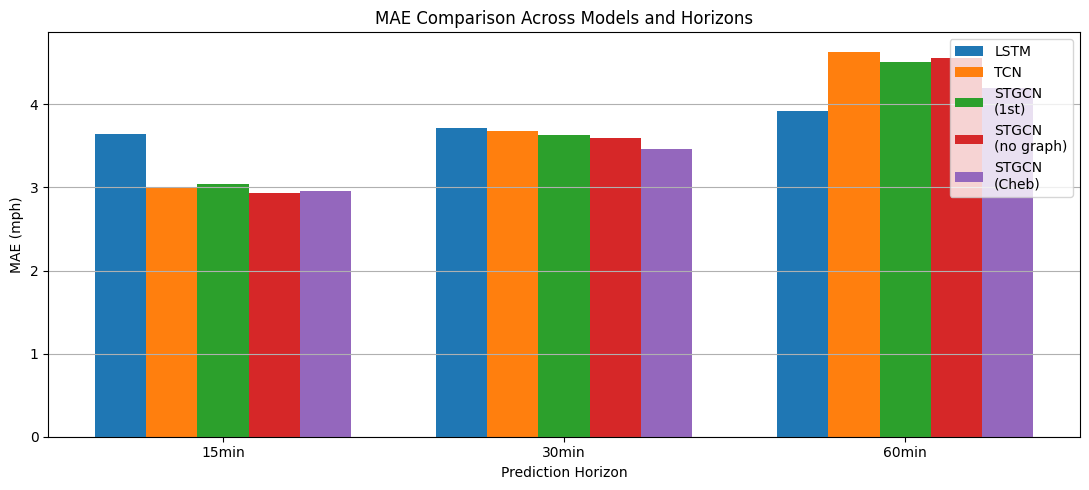

In [57]:
def get_mae_by_horizon(targets, preds, horizons=[3, 6, 12]):
    maes = []
    for h in horizons:
        t = targets[:, h-1, :]
        p = preds[:, h-1, :]
        maes.append(np.mean(np.abs(t - p)))
    return maes

models = ['LSTM', 'TCN', 'STGCN\n(1st)', 'STGCN\n(no graph)', 'STGCN\n(Cheb)']
mae_values = [
    get_mae_by_horizon(lstm_targets_denorm, lstm_preds_denorm),
    get_mae_by_horizon(tcn_targets_denorm, tcn_preds_denorm),
    get_mae_by_horizon(stgcn_targets_denorm, stgcn_preds_denorm),
    get_mae_by_horizon(ablation_targets_denorm, ablation_preds_denorm),
    get_mae_by_horizon(cheb_targets_denorm, cheb_preds_denorm),
]

x = np.arange(3)
width = 0.15

fig, ax = plt.subplots(figsize=(11, 5))
for i, (model, maes) in enumerate(zip(models, mae_values)):
    ax.bar(x + i * width, maes, width, label=model)

ax.set_xlabel('Prediction Horizon')
ax.set_ylabel('MAE (mph)')
ax.set_title('MAE Comparison Across Models and Horizons')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(['15min', '30min', '60min'])
ax.legend()
ax.grid(True, axis='y')
plt.tight_layout()
plt.show()

In [58]:
# find sensor where STGCN is much better than LSTM
lstm_mae_per_sensor = np.mean(np.abs(
    lstm_targets_denorm - lstm_preds_denorm
), axis=(0, 1))

stgcn_mae_per_sensor = np.mean(np.abs(
    stgcn_targets_denorm - stgcn_preds_denorm
), axis=(0, 1))

# difference: LSTM MAE - STGCN MAE, bigger = STGCN wins more
improvement = lstm_mae_per_sensor - stgcn_mae_per_sensor
best_contrast_sensor = improvement.argsort()[-1]

print(f"Best contrast sensor: {best_contrast_sensor}")
print(f"LSTM MAE: {lstm_mae_per_sensor[best_contrast_sensor]:.4f}")
print(f"STGCN MAE: {stgcn_mae_per_sensor[best_contrast_sensor]:.4f}")
print(f"Improvement: {improvement[best_contrast_sensor]:.4f}")

Best contrast sensor: 82
LSTM MAE: 8.1750
STGCN MAE: 4.8825
Improvement: 3.2925


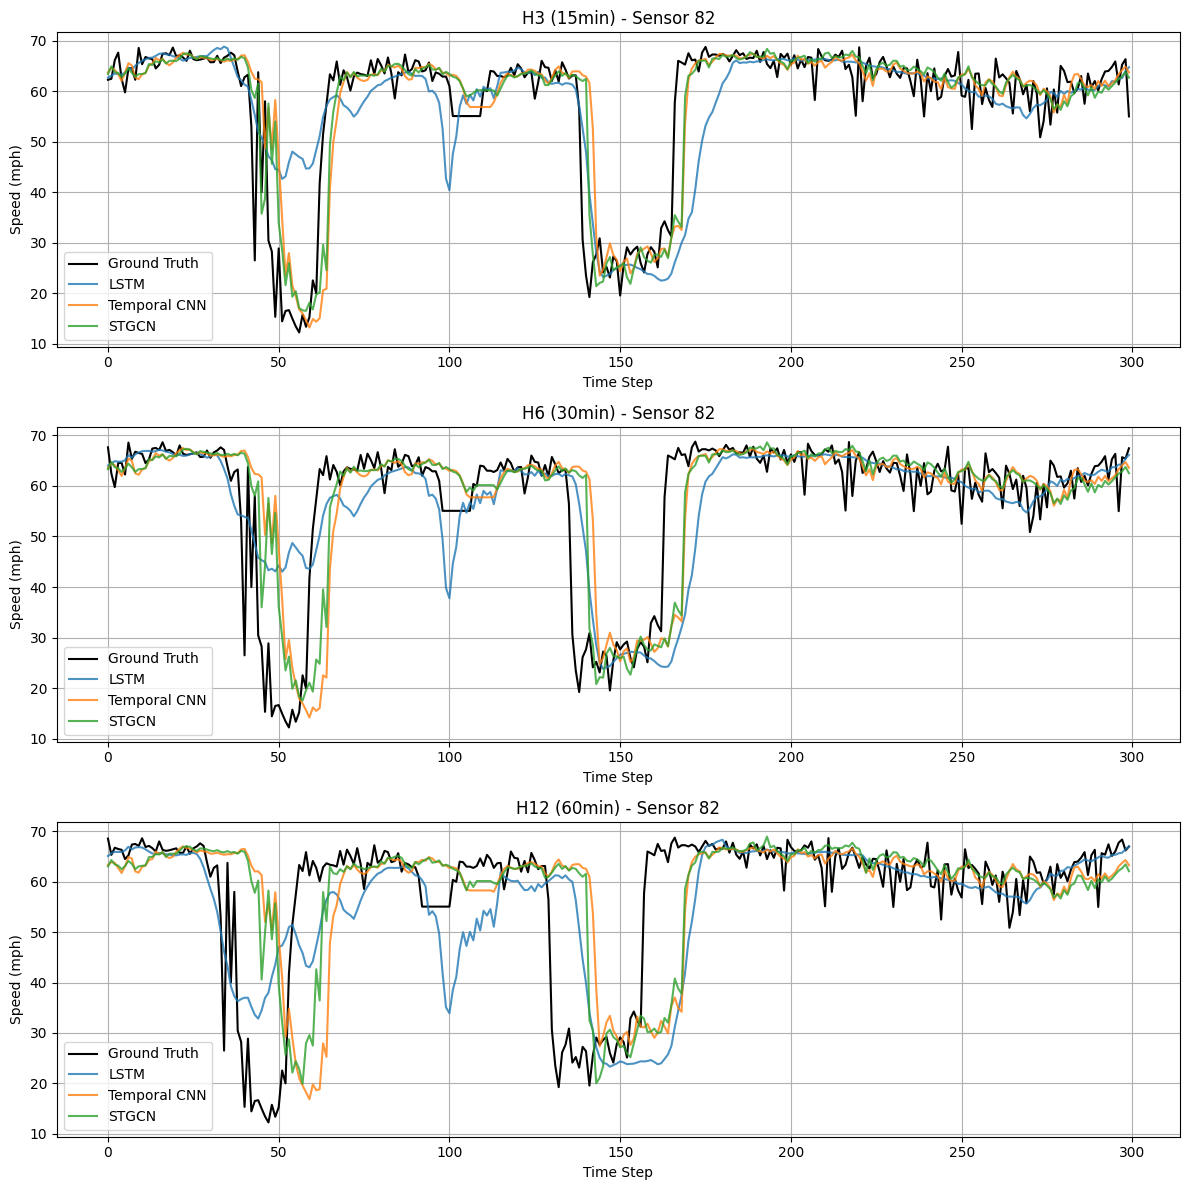

In [59]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
horizons = [3, 6, 12]
sensor_idx = best_contrast_sensor
num_points = 300

for ax, h in zip(axes, horizons):
    ax.plot(lstm_targets_denorm[:num_points, h-1, sensor_idx],
            label="Ground Truth", color="black")
    ax.plot(lstm_preds_denorm[:num_points, h-1, sensor_idx],
            label="LSTM", alpha=0.8)
    ax.plot(tcn_preds_denorm[:num_points, h-1, sensor_idx],
            label="Temporal CNN", alpha=0.8)
    ax.plot(stgcn_preds_denorm[:num_points, h-1, sensor_idx],
            label="STGCN", alpha=0.8)
    ax.set_title(f"H{h} ({h*5}min) - Sensor {sensor_idx}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Speed (mph)")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

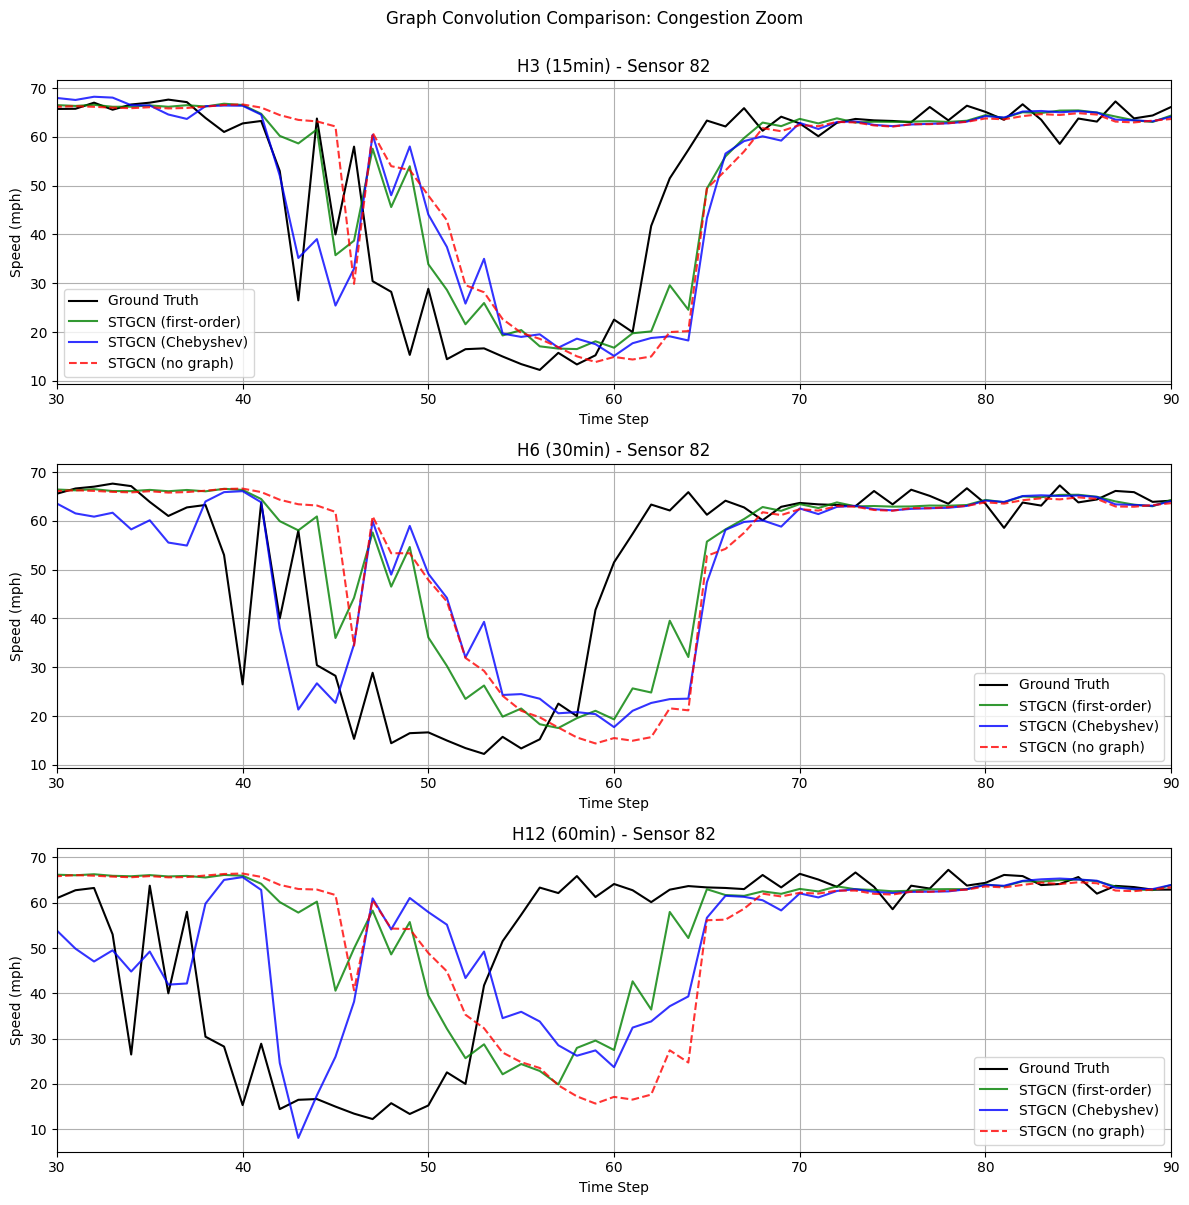

In [60]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))
horizons = [3, 6, 12]
sensor_idx = best_contrast_sensor
num_points = 300

for ax, h in zip(axes, horizons):
    ax.plot(stgcn_targets_denorm[:num_points, h-1, sensor_idx],
            label="Ground Truth", color="black")
    ax.plot(stgcn_preds_denorm[:num_points, h-1, sensor_idx],
            label="STGCN (first-order)", color="green", alpha=0.8)
    ax.plot(cheb_preds_denorm[:num_points, h-1, sensor_idx],
            label="STGCN (Chebyshev)", color="blue", alpha=0.8)
    ax.plot(ablation_preds_denorm[:num_points, h-1, sensor_idx],
            label="STGCN (no graph)", color="red", alpha=0.8, linestyle='--')
    ax.set_title(f"H{h} ({h*5}min) - Sensor {sensor_idx}")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Speed (mph)")
    ax.set_xlim(30, 90)
    ax.legend()
    ax.grid(True)

plt.suptitle("Graph Convolution Comparison: Congestion Zoom", y=1.0)
plt.tight_layout()
plt.show()

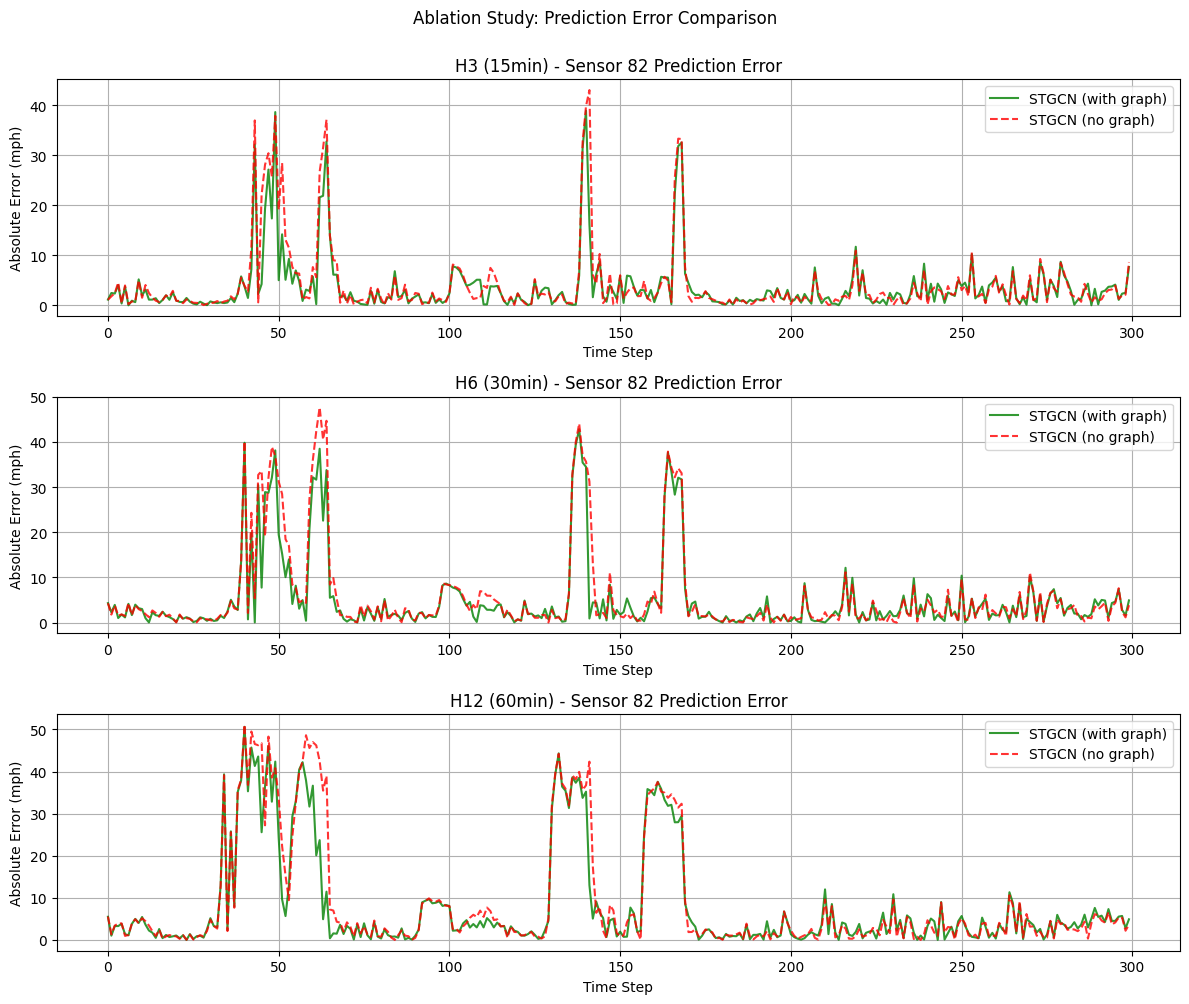

In [61]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
horizons = [3, 6, 12]
sensor_idx = best_contrast_sensor
num_points = 300

for ax, h in zip(axes, horizons):
    gt = stgcn_targets_denorm[:num_points, h-1, sensor_idx]
    err_graph = np.abs(stgcn_preds_denorm[:num_points, h-1, sensor_idx] - gt)
    err_no_graph = np.abs(ablation_preds_denorm[:num_points, h-1, sensor_idx] - gt)

    ax.plot(err_graph, label="STGCN (with graph)", color="green", alpha=0.8)
    ax.plot(err_no_graph, label="STGCN (no graph)", color="red", alpha=0.8, linestyle='--')
    ax.set_title(f"H{h} ({h*5}min) - Sensor {sensor_idx} Prediction Error")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Absolute Error (mph)")
    ax.legend()
    ax.grid(True)

plt.suptitle("Ablation Study: Prediction Error Comparison", y=1.0)
plt.tight_layout()
plt.show()

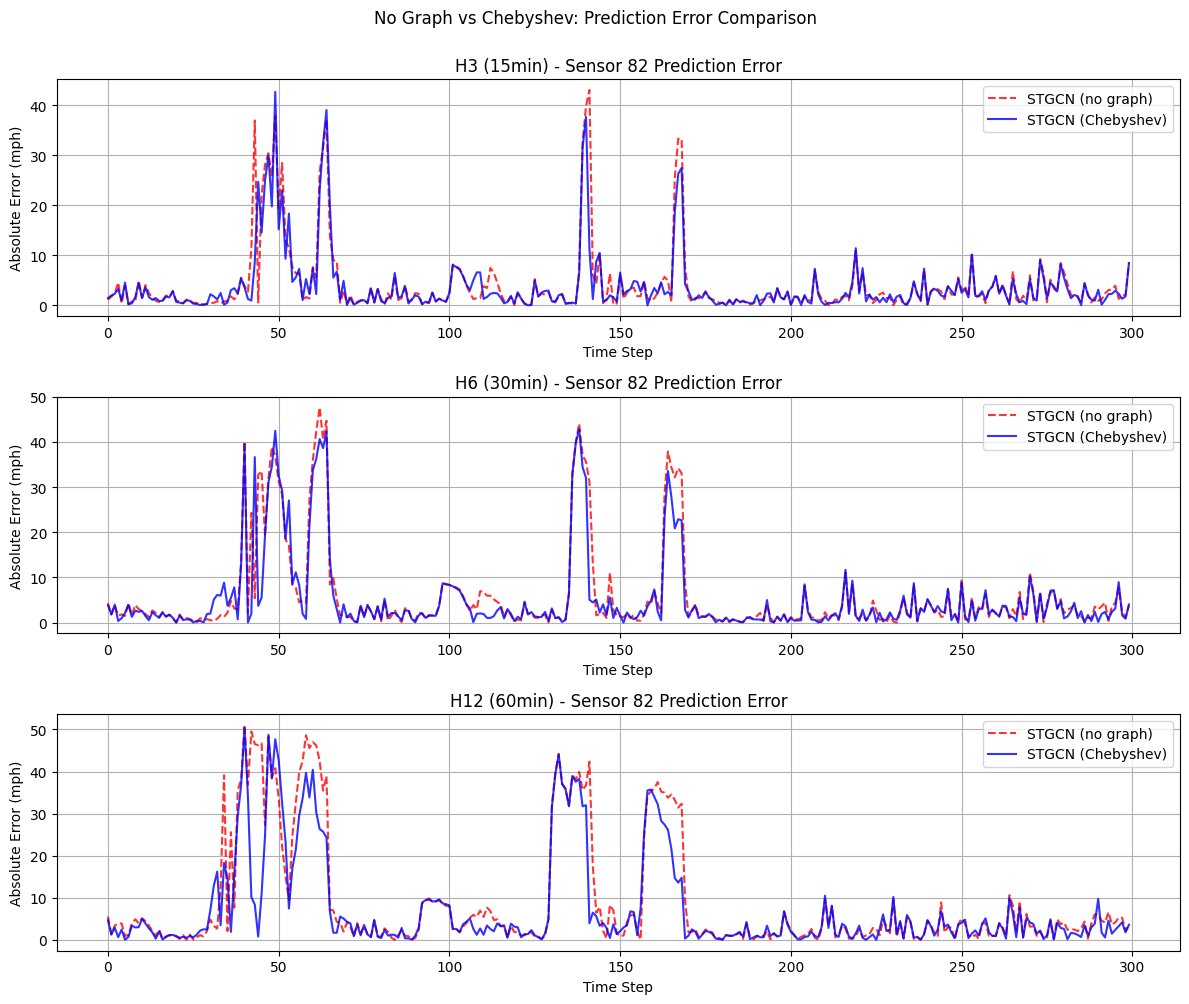

In [62]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
horizons = [3, 6, 12]
sensor_idx = best_contrast_sensor
num_points = 300

for ax, h in zip(axes, horizons):
    gt = stgcn_targets_denorm[:num_points, h-1, sensor_idx]
    err_no_graph = np.abs(ablation_preds_denorm[:num_points, h-1, sensor_idx] - gt)
    err_cheb = np.abs(cheb_preds_denorm[:num_points, h-1, sensor_idx] - gt)

    ax.plot(err_no_graph, label="STGCN (no graph)", color="red", alpha=0.8, linestyle='--')
    ax.plot(err_cheb, label="STGCN (Chebyshev)", color="blue", alpha=0.8)
    ax.set_title(f"H{h} ({h*5}min) - Sensor {sensor_idx} Prediction Error")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Absolute Error (mph)")
    ax.legend()
    ax.grid(True)

plt.suptitle("No Graph vs Chebyshev: Prediction Error Comparison", y=1.0)
plt.tight_layout()
plt.show()

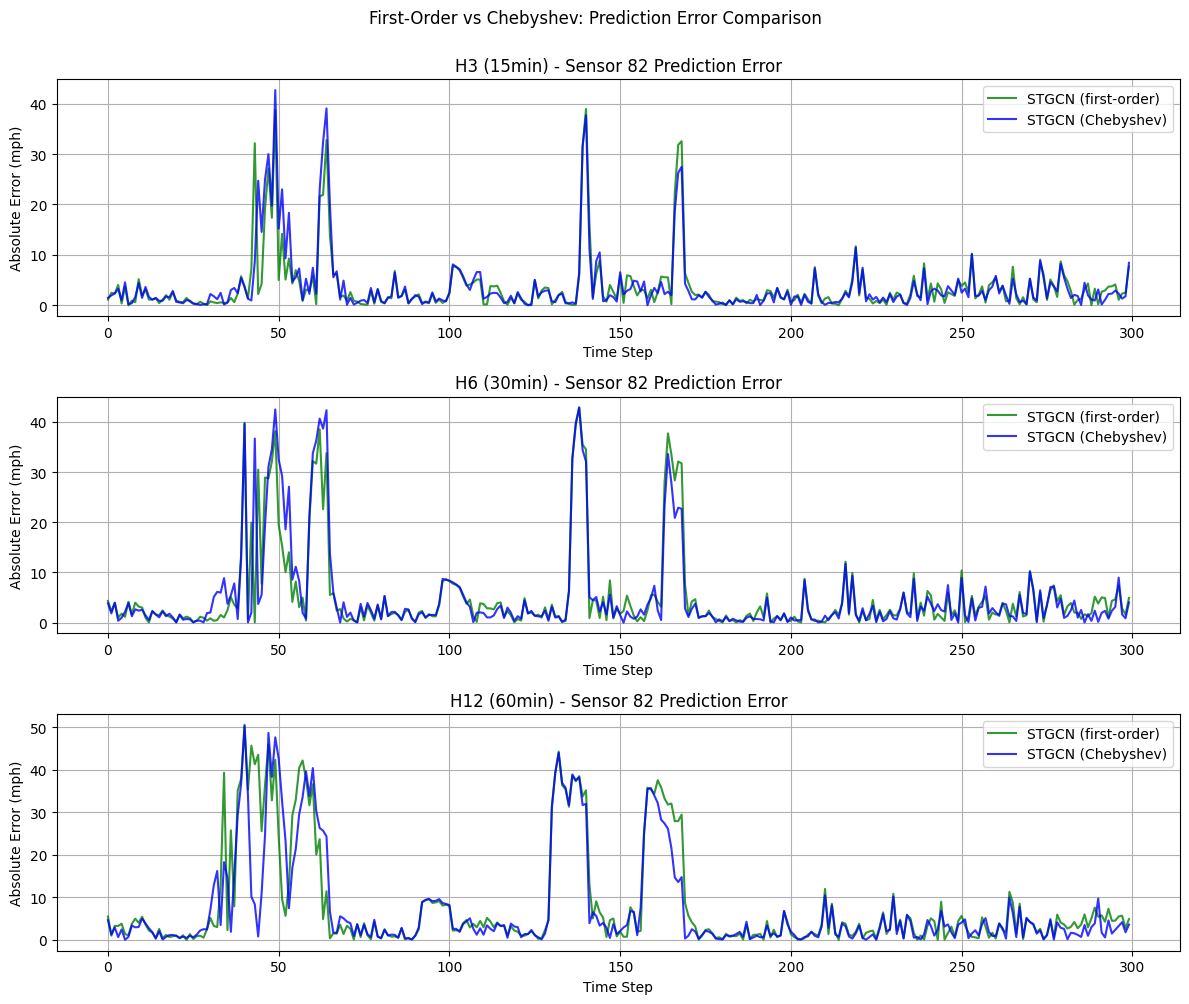

In [63]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10))
horizons = [3, 6, 12]
sensor_idx = best_contrast_sensor
num_points = 300

for ax, h in zip(axes, horizons):
    gt = stgcn_targets_denorm[:num_points, h-1, sensor_idx]
    err_first = np.abs(stgcn_preds_denorm[:num_points, h-1, sensor_idx] - gt)
    err_cheb = np.abs(cheb_preds_denorm[:num_points, h-1, sensor_idx] - gt)

    ax.plot(err_first, label="STGCN (first-order)", color="green", alpha=0.8)
    ax.plot(err_cheb, label="STGCN (Chebyshev)", color="blue", alpha=0.8)
    ax.set_title(f"H{h} ({h*5}min) - Sensor {sensor_idx} Prediction Error")
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Absolute Error (mph)")
    ax.legend()
    ax.grid(True)

plt.suptitle("First-Order vs Chebyshev: Prediction Error Comparison", y=1.0)
plt.tight_layout()
plt.show()

In [64]:
import subprocess
subprocess.run(["jupyter", "nbconvert", "--to", "html", "/content/ECE1508Project.ipynb"])

CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'html', '/content/ECE1508Project.ipynb'], returncode=255)